Dataset shape: (569, 30)
Classes: ['malignant' 'benign']

🎯 Accuracy: 0.9825 (98.25%)

📊 Detailed Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


🔢 Confusion Matrix:
[[41  1]
 [ 1 71]]


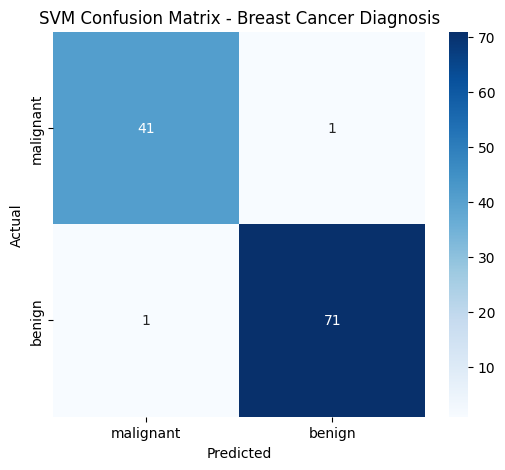


Number of Support Vectors: [51 46]
Support Vectors per class: [51 46]


In [1]:
# =====================================================
# REAL-WORLD EXAMPLE: SVM for Breast Cancer Diagnosis
# =====================================================
# Dataset: Breast Cancer Wisconsin (Diagnostic)
#   - 569 samples
#   - 30 real-valued features (mean, std, worst of nucleus measurements)
#   - Binary target: 0 = malignant, 1 = benign
# Why SVM? Excellent for high-dimensional medical data,
# maximizes margin, and works very well with RBF kernel.

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------- 1. Load Data -------------------
cancer = datasets.load_breast_cancer()
X = cancer.data          # features
y = cancer.target        # labels (0 = malignant, 1 = benign)

print("Dataset shape:", X.shape)
print("Classes:", cancer.target_names)

# ------------------- 2. Split Data -------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------- 3. Feature Scaling (CRITICAL for SVM) -------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ------------------- 4. Train SVM Model -------------------
# RBF kernel is the most common choice for real-world non-linear data
svm_model = SVC(
    kernel='rbf',      # non-linear kernel
    C=1.0,             # regularization (higher = less tolerance for errors)
    gamma='scale',     # auto scaling for RBF
    probability=True,  # enables predict_proba if needed
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# ------------------- 5. Make Predictions -------------------
y_pred = svm_model.predict(X_test_scaled)

# ------------------- 6. EVALUATE THE MODEL -------------------
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

print("\n🔢 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Optional: Visual Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.title('SVM Confusion Matrix - Breast Cancer Diagnosis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ------------------- 7. Extra Insights -------------------
print(f"\nNumber of Support Vectors: {svm_model.n_support_}")
print(f"Support Vectors per class: {svm_model.n_support_}")